# Phase 5 | Segmentation and Collections Strategy

**Project**: Beyond Risk Scores: Uplift-Driven Financial Intervention for Loan Default Prevention

Phase 4 identified 29,131 Persuadables, 26,865 Sure Things, and 15,908 Sleeping Dogs.
This notebook segments the Persuadables by income, age, employment, education, and loan
type to determine where the intervention works best and build a prioritized collections
playbook that a non-technical manager can act on directly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = ['steelblue', 'cadetblue', 'skyblue', 'lightblue']

## Step 1 | Load Uplift Scores

The dataset from Phase 4 contains 71,904 customers with uplift scores from three models,
baseline risk, quadrant assignment, and targeting priority. This notebook focuses on the
29,131 Persuadables to determine where within that group the intervention works best.

In [3]:
df = pd.read_csv('../data/processed/uplift_scores.csv')

persuadables = df[df['quadrant'] == 'Persuadables'].copy()
sure_things = df[df['quadrant'] == 'Sure Things'].copy()
sleeping_dogs = df[df['quadrant'] == 'Sleeping Dogs'].copy()

print("=" * 45)
print("Uplift Scores Loaded")
print("=" * 45)
print(f"Total customers        : {len(df):,}")
print(f"Persuadables           : {len(persuadables):,}")
print(f"Sure Things            : {len(sure_things):,}")
print(f"Sleeping Dogs          : {len(sleeping_dogs):,}")
print(f"Columns                : {df.shape[1]}")
print("=" * 45)

Uplift Scores Loaded
Total customers        : 71,904
Persuadables           : 29,131
Sure Things            : 26,865
Sleeping Dogs          : 15,908
Columns                : 96


## Step 2 | The Persuadable Archetype

Who are the 29,131 customers that respond to intervention? Averages alone do not tell the
story. This step builds a persona by comparing Persuadables against Sure Things and
Sleeping Dogs across every key dimension. The goal is not just statistical. It is to give
the collections team a mental picture of who they are calling and why that person responds.

In [4]:
# Compare key features across quadrants
profile_features = {
    'AGE_YEARS': 'Age (years)',
    'AMT_INCOME_TOTAL': 'Income (CU)',
    'AMT_CREDIT': 'Loan Amount (CU)',
    'AMT_ANNUITY': 'Annual Payment (CU)',
    'DEBT_TO_INCOME': 'Debt-to-Income',
    'EXT_SOURCE_2': 'External Score 2',
    'EXT_SOURCE_3': 'External Score 3',
    'CREDIT_TO_GOODS': 'Credit-to-Goods',
    'baseline_risk': 'Baseline Default Risk',
    'uplift_t_learner': 'Uplift Score'
}

print("=" * 75)
print("Quadrant Profiles: Persuadables vs Sure Things vs Sleeping Dogs")
print("=" * 75)
print()
print(f"{'Feature':<25} {'Persuadables':>15} {'Sure Things':>15} {'Sleeping Dogs':>15}")
print("-" * 72)

for col, label in profile_features.items():
    p_val = persuadables[col].mean()
    s_val = sure_things[col].mean()
    d_val = sleeping_dogs[col].mean()
    
    if p_val > 1000:
        print(f"{label:<25} {p_val:>15,.0f} {s_val:>15,.0f} {d_val:>15,.0f}")
    else:
        print(f"{label:<25} {p_val:>15.4f} {s_val:>15.4f} {d_val:>15.4f}")

print("=" * 75)

Quadrant Profiles: Persuadables vs Sure Things vs Sleeping Dogs

Feature                      Persuadables     Sure Things   Sleeping Dogs
------------------------------------------------------------------------
Age (years)                       42.3345         51.3824         46.1412
Income (CU)                       121,734         133,142         123,784
Loan Amount (CU)                  708,024         838,174         763,374
Annual Payment (CU)                33,308          36,922          33,684
Debt-to-Income                     0.2849          0.2880          0.2884
External Score 2                   0.3967          0.5733          0.4492
External Score 3                   0.4506          0.6006          0.4893
Credit-to-Goods                    1.1489          1.0987          1.1247
Baseline Default Risk              0.1615          0.0368          0.0720
Uplift Score                       0.0770          0.0126         -0.0418


### The Persuadable Persona

The data paints a clear picture of who responds to a collections call.

**The Persuadable** is a 42-year-old mid-career professional earning 121,734 CU with a loan
of 708,024 CU. They spend 28.5% of their income on loan repayment. Their external credit
scores are moderate (0.40 and 0.45), not terrible but noticeably below the Sure Things
(0.57 and 0.60). They borrowed slightly more than the goods price (credit-to-goods ratio
of 1.15), suggesting they stretched to cover fees and insurance. Their baseline default
risk is 16.2%.

This person is under real financial pressure but is not in freefall. They have income. They
have a job. They took on slightly more than they should have. When a collections agent calls
with a restructuring offer, they have the capacity to act on it. That is why the intervention
works: it gives a stressed-but-capable person a path back.

**Contrast with Sure Things**: 9 years older (51), higher income (133K), stronger external
scores (0.57, 0.60), and only 3.7% baseline risk. These customers are financially stable.
They do not need a call.

**Contrast with Sleeping Dogs**: Similar income (123K) and DTI (0.29) to Persuadables, but
slightly older (46) with slightly better external scores (0.45, 0.49). Their baseline risk
is only 7.2%. These customers are managing fine on their own. The call disrupts them,
possibly triggering anxiety or adversarial behavior that leads to default.

**The key differentiator** is not income or debt load. Persuadables, Sure Things, and Sleeping
Dogs have similar DTI ratios (0.285 to 0.288). What separates them is a combination of age,
external scores, and baseline risk. The Persuadable is younger, has weaker external scores,
and is at genuinely high risk of default. The intervention works because it reaches someone
at a tipping point.

## Step 3 | Segment by Income Level

Not all Persuadables are equal. A Persuadable earning 200,000 CU has more capacity to
recover than one earning 80,000 CU. This step splits Persuadables into income bands and
measures uplift, default rates, and recovery value within each band. The goal is to
determine if income level affects intervention effectiveness.

In [5]:
# Income bands for Persuadables
persuadables['income_band'] = pd.qcut(
    persuadables['AMT_INCOME_TOTAL'], q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High'],
    duplicates='drop'
)

income_seg = persuadables.groupby('income_band', observed=True).agg(
    customers=('TARGET', 'count'),
    avg_income=('AMT_INCOME_TOTAL', 'mean'),
    avg_loan=('AMT_CREDIT', 'mean'),
    avg_uplift=('uplift_t_learner', 'mean'),
    avg_risk=('baseline_risk', 'mean'),
    treat_default=('TARGET', lambda x: x[persuadables.loc[x.index, 'TREATMENT'] == 1].mean() * 100),
    ctrl_default=('TARGET', lambda x: x[persuadables.loc[x.index, 'TREATMENT'] == 0].mean() * 100)
).reset_index()

income_seg['uplift_pp'] = income_seg['ctrl_default'] - income_seg['treat_default']

# Recovery value per segment
cost_per_call = 50
lgd = 0.45

income_seg['recovery_per_save'] = income_seg['avg_loan'] * lgd
income_seg['net_value_per_customer'] = (
    income_seg['uplift_pp'] / 100 * income_seg['recovery_per_save']
) - cost_per_call

print("=" * 75)
print("Persuadables by Income Band")
print("=" * 75)
print()
for _, row in income_seg.iterrows():
    print(f"  {row['income_band']}")
    print(f"    Customers          : {int(row['customers']):,}")
    print(f"    Avg income         : {row['avg_income']:,.0f} CU")
    print(f"    Avg loan           : {row['avg_loan']:,.0f} CU")
    print(f"    Treatment default  : {row['treat_default']:.2f}%")
    print(f"    Control default    : {row['ctrl_default']:.2f}%")
    print(f"    Uplift             : {row['uplift_pp']:.2f} pp")
    print(f"    Net value per call : {row['net_value_per_customer']:,.0f} CU")
    print()

# Drop temporary column
persuadables.drop(columns=['income_band'], inplace=True)
print("=" * 75)

Persuadables by Income Band

  Low
    Customers          : 9,753
    Avg income         : 76,255 CU
    Avg loan           : 522,961 CU
    Treatment default  : 6.83%
    Control default    : 22.26%
    Uplift             : 15.43 pp
    Net value per call : 36,265 CU

  Mid-Low
    Customers          : 6,209
    Avg income         : 109,271 CU
    Avg loan           : 667,593 CU
    Treatment default  : 7.39%
    Control default    : 20.99%
    Uplift             : 13.60 pp
    Net value per call : 40,796 CU

  Mid-High
    Customers          : 5,981
    Avg income         : 132,261 CU
    Avg loan           : 771,875 CU
    Treatment default  : 6.80%
    Control default    : 20.38%
    Uplift             : 13.58 pp
    Net value per call : 47,121 CU

  High
    Customers          : 7,188
    Avg income         : 185,446 CU
    Avg loan           : 940,920 CU
    Treatment default  : 6.43%
    Control default    : 18.74%
    Uplift             : 12.30 pp
    Net value per call : 52,05

### Income Segmentation Finding

The intervention works across all income bands but with a clear tradeoff.

Low income Persuadables respond the strongest (15.43 pp uplift) but their smaller loans
mean each prevented default saves less. High income Persuadables respond slightly less
(12.30 pp) but each prevented default saves 52,050 CU per call versus 36,265 CU for the
low income group.

The collections team has a choice: maximize the number of recoveries (start with low income)
or maximize the value recovered (start with high income). The priority matrix in Step 9 will
resolve this by crossing uplift against loan value to produce a single ranking.

No income band should be excluded. All four deliver strong positive net value per call,
ranging from 36,265 to 52,050 CU against a 50 CU call cost.

## Step 4 | Segment by Age Group

Phase 1 found that younger customers default more. Phase 4 found that Persuadables average
42 years old compared to 51 for Sure Things. This step tests whether age affects how well
the intervention works within the Persuadable group itself.

In [6]:
persuadables['age_group'] = pd.cut(
    persuadables['AGE_YEARS'],
    bins=[20, 30, 40, 50, 60, 70],
    labels=['20-30', '30-40', '40-50', '50-60', '60-70'],
    right=False
)

age_seg = persuadables.groupby('age_group', observed=True).agg(
    customers=('TARGET', 'count'),
    avg_income=('AMT_INCOME_TOTAL', 'mean'),
    avg_loan=('AMT_CREDIT', 'mean'),
    avg_uplift=('uplift_t_learner', 'mean'),
    avg_risk=('baseline_risk', 'mean'),
    treat_default=('TARGET', lambda x: x[persuadables.loc[x.index, 'TREATMENT'] == 1].mean() * 100),
    ctrl_default=('TARGET', lambda x: x[persuadables.loc[x.index, 'TREATMENT'] == 0].mean() * 100)
).reset_index()

age_seg['uplift_pp'] = age_seg['ctrl_default'] - age_seg['treat_default']
age_seg['recovery_per_save'] = age_seg['avg_loan'] * lgd
age_seg['net_value_per_call'] = (
    age_seg['uplift_pp'] / 100 * age_seg['recovery_per_save']
) - cost_per_call

print("=" * 75)
print("Persuadables by Age Group")
print("=" * 75)
print()
for _, row in age_seg.iterrows():
    print(f"  {row['age_group']}")
    print(f"    Customers          : {int(row['customers']):,}")
    print(f"    Avg income         : {row['avg_income']:,.0f} CU")
    print(f"    Avg loan           : {row['avg_loan']:,.0f} CU")
    print(f"    Treatment default  : {row['treat_default']:.2f}%")
    print(f"    Control default    : {row['ctrl_default']:.2f}%")
    print(f"    Uplift             : {row['uplift_pp']:.2f} pp")
    print(f"    Net value per call : {row['net_value_per_call']:,.0f} CU")
    print()

persuadables.drop(columns=['age_group'], inplace=True)
print("=" * 75)

Persuadables by Age Group

  20-30
    Customers          : 5,146
    Avg income         : 123,213 CU
    Avg loan           : 631,171 CU
    Treatment default  : 7.90%
    Control default    : 24.58%
    Uplift             : 16.68 pp
    Net value per call : 47,336 CU

  30-40
    Customers          : 9,101
    Avg income         : 126,361 CU
    Avg loan           : 709,047 CU
    Treatment default  : 7.91%
    Control default    : 19.70%
    Uplift             : 11.78 pp
    Net value per call : 37,545 CU

  40-50
    Customers          : 6,234
    Avg income         : 125,966 CU
    Avg loan           : 745,248 CU
    Treatment default  : 6.60%
    Control default    : 21.09%
    Uplift             : 14.48 pp
    Net value per call : 48,521 CU

  50-60
    Customers          : 5,714
    Avg income         : 116,328 CU
    Avg loan           : 741,495 CU
    Treatment default  : 5.68%
    Control default    : 18.60%
    Uplift             : 12.92 pp
    Net value per call : 43,077 C

### Age Segmentation Finding

The intervention works across all age groups with no weak segments.

The 20-30 group responds the strongest (16.68 pp uplift) followed closely by the 60-70
group (16.21 pp). The youngest Persuadables are early in their careers with less financial
resilience, making a restructuring call highly impactful. The oldest group may be
approaching retirement with fixed income concerns, making them equally responsive to help.

The 30-40 group shows the lowest uplift (11.78 pp) despite being the largest segment
(9,101 customers). Mid-career professionals may have more competing financial obligations
that limit how much a single intervention can help.

Net value per call is positive across all groups, ranging from 37,545 CU (30-40) to
50,661 CU (60-70). No age group should be deprioritized. The priority matrix in Step 9
will incorporate age alongside income and loan value for the final ranking.

## Step 5 | Segment by Employment Type

Phase 1 found that among large customer segments, Working customers have the highest default
rate at 9.59% with 158,774 customers. This step tests whether employment type affects
intervention effectiveness within Persuadables. A working customer with steady income may
respond differently to a collections call than a pensioner or a commercial associate.

In [7]:
emp_seg = persuadables.groupby('NAME_INCOME_TYPE', observed=True).agg(
    customers=('TARGET', 'count'),
    avg_income=('AMT_INCOME_TOTAL', 'mean'),
    avg_loan=('AMT_CREDIT', 'mean'),
    avg_uplift=('uplift_t_learner', 'mean'),
    avg_risk=('baseline_risk', 'mean'),
    treat_default=('TARGET', lambda x: x[persuadables.loc[x.index, 'TREATMENT'] == 1].mean() * 100),
    ctrl_default=('TARGET', lambda x: x[persuadables.loc[x.index, 'TREATMENT'] == 0].mean() * 100)
).reset_index()

emp_seg['uplift_pp'] = emp_seg['ctrl_default'] - emp_seg['treat_default']
emp_seg['recovery_per_save'] = emp_seg['avg_loan'] * lgd
emp_seg['net_value_per_call'] = (
    emp_seg['uplift_pp'] / 100 * emp_seg['recovery_per_save']
) - cost_per_call

# Filter to segments with at least 100 customers
emp_seg = emp_seg[emp_seg['customers'] >= 100].sort_values('uplift_pp', ascending=False)

print("=" * 75)
print("Persuadables by Employment Type (segments >= 100 customers)")
print("=" * 75)
print()
for _, row in emp_seg.iterrows():
    print(f"  {row['NAME_INCOME_TYPE']}")
    print(f"    Customers          : {int(row['customers']):,}")
    print(f"    Avg income         : {row['avg_income']:,.0f} CU")
    print(f"    Avg loan           : {row['avg_loan']:,.0f} CU")
    print(f"    Treatment default  : {row['treat_default']:.2f}%")
    print(f"    Control default    : {row['ctrl_default']:.2f}%")
    print(f"    Uplift             : {row['uplift_pp']:.2f} pp")
    print(f"    Net value per call : {row['net_value_per_call']:,.0f} CU")
    print()
print("=" * 75)

Persuadables by Employment Type (segments >= 100 customers)

  Working
    Customers          : 16,738
    Avg income         : 121,893 CU
    Avg loan           : 690,965 CU
    Treatment default  : 7.73%
    Control default    : 22.54%
    Uplift             : 14.81 pp
    Net value per call : 46,009 CU

  Pensioner
    Customers          : 4,997
    Avg income         : 103,602 CU
    Avg loan           : 686,698 CU
    Treatment default  : 4.89%
    Control default    : 18.76%
    Uplift             : 13.86 pp
    Net value per call : 42,788 CU

  Commercial associate
    Customers          : 5,459
    Avg income         : 137,955 CU
    Avg loan           : 758,369 CU
    Treatment default  : 6.44%
    Control default    : 18.84%
    Uplift             : 12.40 pp
    Net value per call : 42,280 CU

  State servant
    Customers          : 1,928
    Avg income         : 121,606 CU
    Avg loan           : 768,034 CU
    Treatment default  : 5.38%
    Control default    : 15.30%
   

### Employment Segmentation Finding

Working customers are the highest-priority employment segment. They are the largest group
(16,738 customers), show the strongest uplift (14.81 pp), and generate 46,009 CU net value
per call. These are people with active income who are stretched but can act on a
restructuring offer.

Pensioners respond nearly as well (13.86 pp) despite lower income. Their financial
obligations are typically more fixed and predictable, making a restructuring offer
easier to commit to.

Commercial associates show solid uplift (12.40 pp) with the highest average income
(137,955 CU) and largest loans (758,369 CU) in the group.

State servants respond the least (9.92 pp) but still deliver 34,232 CU net value per call.
Their lower uplift may reflect greater job stability and access to employer-based financial
support, reducing the marginal impact of an external collections call.

No employment segment should be excluded. All four deliver strong positive returns.

## Step 6 | Segment by Education Level

Phase 1 found that Secondary education customers are the largest actionable segment at
8.94% default rate with 218,391 customers. This step tests whether education level affects
how Persuadables respond to intervention.

In [8]:
edu_seg = persuadables.groupby('NAME_EDUCATION_TYPE', observed=True).agg(
    customers=('TARGET', 'count'),
    avg_income=('AMT_INCOME_TOTAL', 'mean'),
    avg_loan=('AMT_CREDIT', 'mean'),
    avg_uplift=('uplift_t_learner', 'mean'),
    avg_risk=('baseline_risk', 'mean'),
    treat_default=('TARGET', lambda x: x[persuadables.loc[x.index, 'TREATMENT'] == 1].mean() * 100),
    ctrl_default=('TARGET', lambda x: x[persuadables.loc[x.index, 'TREATMENT'] == 0].mean() * 100)
).reset_index()

edu_seg['uplift_pp'] = edu_seg['ctrl_default'] - edu_seg['treat_default']
edu_seg['recovery_per_save'] = edu_seg['avg_loan'] * lgd
edu_seg['net_value_per_call'] = (
    edu_seg['uplift_pp'] / 100 * edu_seg['recovery_per_save']
) - cost_per_call

edu_seg = edu_seg[edu_seg['customers'] >= 100].sort_values('uplift_pp', ascending=False)

print("=" * 75)
print("Persuadables by Education Level (segments >= 100 customers)")
print("=" * 75)
print()
for _, row in edu_seg.iterrows():
    print(f"  {row['NAME_EDUCATION_TYPE']}")
    print(f"    Customers          : {int(row['customers']):,}")
    print(f"    Avg income         : {row['avg_income']:,.0f} CU")
    print(f"    Avg loan           : {row['avg_loan']:,.0f} CU")
    print(f"    Treatment default  : {row['treat_default']:.2f}%")
    print(f"    Control default    : {row['ctrl_default']:.2f}%")
    print(f"    Uplift             : {row['uplift_pp']:.2f} pp")
    print(f"    Net value per call : {row['net_value_per_call']:,.0f} CU")
    print()
print("=" * 75)

Persuadables by Education Level (segments >= 100 customers)

  Lower secondary
    Customers          : 550
    Avg income         : 103,383 CU
    Avg loan           : 604,129 CU
    Treatment default  : 8.13%
    Control default    : 25.84%
    Uplift             : 17.72 pp
    Net value per call : 48,111 CU

  Secondary / secondary special
    Customers          : 22,860
    Avg income         : 118,217 CU
    Avg loan           : 694,031 CU
    Treatment default  : 7.20%
    Control default    : 22.16%
    Uplift             : 14.96 pp
    Net value per call : 46,673 CU

  Incomplete higher
    Customers          : 866
    Avg income         : 132,858 CU
    Avg loan           : 678,897 CU
    Treatment default  : 7.48%
    Control default    : 19.06%
    Uplift             : 11.58 pp
    Net value per call : 35,315 CU

  Higher education
    Customers          : 4,847
    Avg income         : 138,376 CU
    Avg loan           : 790,660 CU
    Treatment default  : 5.00%
    Control

### Education Segmentation Finding

Education level shows the clearest gradient among all segments. Lower education customers
respond significantly more to intervention than higher education customers.

Lower secondary shows the strongest uplift at 17.72 pp but is a small group (550 customers).
Secondary education is the priority segment: 22,860 customers (78% of all Persuadables) with
14.96 pp uplift and 46,673 CU net value per call. This is the largest, most actionable
segment in the entire portfolio.

Higher education customers respond the least (8.47 pp). Their higher income (138,376 CU),
larger loans (790,660 CU), and lower baseline default rate suggest they have more financial
resources and alternatives available, reducing the marginal impact of a collections call.

The pattern makes sense. Customers with lower education levels may have fewer options for
financial guidance and restructuring outside of what the bank offers. The collections call
is not just a reminder but a financial lifeline they may not have access to otherwise.

## Step 7 | Segment by Loan Type

The Home Credit dataset has two contract types: Cash loans and Revolving loans. Phase 1
found that cash loans cover a wider range of goods prices while revolving loans concentrate
at lower values. This step tests whether loan type affects intervention effectiveness.

In [9]:
loan_seg = persuadables.groupby('NAME_CONTRACT_TYPE', observed=True).agg(
    customers=('TARGET', 'count'),
    avg_income=('AMT_INCOME_TOTAL', 'mean'),
    avg_loan=('AMT_CREDIT', 'mean'),
    avg_uplift=('uplift_t_learner', 'mean'),
    avg_risk=('baseline_risk', 'mean'),
    treat_default=('TARGET', lambda x: x[persuadables.loc[x.index, 'TREATMENT'] == 1].mean() * 100),
    ctrl_default=('TARGET', lambda x: x[persuadables.loc[x.index, 'TREATMENT'] == 0].mean() * 100)
).reset_index()

loan_seg['uplift_pp'] = loan_seg['ctrl_default'] - loan_seg['treat_default']
loan_seg['recovery_per_save'] = loan_seg['avg_loan'] * lgd
loan_seg['net_value_per_call'] = (
    loan_seg['uplift_pp'] / 100 * loan_seg['recovery_per_save']
) - cost_per_call

print("=" * 75)
print("Persuadables by Loan Type")
print("=" * 75)
print()
for _, row in loan_seg.iterrows():
    print(f"  {row['NAME_CONTRACT_TYPE']}")
    print(f"    Customers          : {int(row['customers']):,}")
    print(f"    Avg income         : {row['avg_income']:,.0f} CU")
    print(f"    Avg loan           : {row['avg_loan']:,.0f} CU")
    print(f"    Treatment default  : {row['treat_default']:.2f}%")
    print(f"    Control default    : {row['ctrl_default']:.2f}%")
    print(f"    Uplift             : {row['uplift_pp']:.2f} pp")
    print(f"    Net value per call : {row['net_value_per_call']:,.0f} CU")
    print()
print("=" * 75)

Persuadables by Loan Type

  Cash loans
    Customers          : 28,941
    Avg income         : 121,743 CU
    Avg loan           : 708,628 CU
    Treatment default  : 6.88%
    Control default    : 20.72%
    Uplift             : 13.84 pp
    Net value per call : 44,091 CU

  Revolving loans
    Customers          : 190
    Avg income         : 120,247 CU
    Avg loan           : 616,026 CU
    Treatment default  : 1.89%
    Control default    : 25.00%
    Uplift             : 23.11 pp
    Net value per call : 64,023 CU



### Loan Type Finding

Cash loans dominate the Persuadable group at 28,941 customers (99.3%). Their uplift of
13.84 pp and net value of 44,091 CU per call confirms they are the core intervention target.

Revolving loans show a striking 23.11 pp uplift and 64,023 CU net value per call. However,
this segment has only 190 customers. The high uplift may partly reflect small sample
volatility rather than a genuinely stronger intervention effect.

For collections strategy, cash loan Persuadables are the priority purely by volume. The
revolving loan finding is directional and worth monitoring in a live deployment, but 190
customers is too few to build a separate strategy around.

## Step 8 | Optimal Targeting Depth

Every Persuadable has a positive uplift score, but not every Persuadable delivers the same
value. As we move down the ranked list, uplift decreases and at some point the cost of the
next call exceeds the expected recovery from that call.

This step plots the cumulative net gain as we call Persuadables from highest uplift to
lowest. The peak of this curve is the exact cutoff point: the number of customers the
collections team should call before the marginal return turns negative.

Optimal Targeting Depth
Total Persuadables     : 29,131
Optimal cutoff         : 29,106 customers
Peak cumulative gain   : 683,509,550 CU

Customers after cutoff deliver negative marginal value.
Calling beyond 29,106 costs more than it recovers.


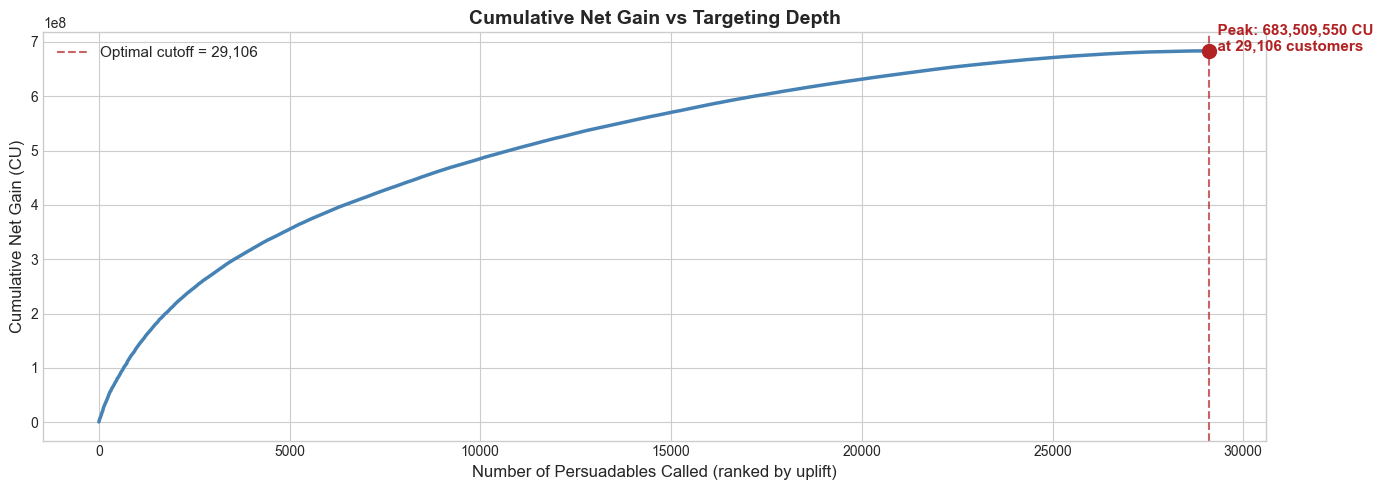

In [10]:
# Rank Persuadables by uplift score (highest first)
ranked = persuadables.sort_values('uplift_t_learner', ascending=False).reset_index(drop=True)

# Per-customer expected value
# Each customer's value = (their uplift score * recovery value per save) - cost per call
ranked['expected_value'] = (ranked['uplift_t_learner'] * ranked['AMT_CREDIT'] * lgd) - cost_per_call
ranked['cumulative_net_gain'] = ranked['expected_value'].cumsum()

# Find optimal cutoff
optimal_idx = ranked['cumulative_net_gain'].idxmax()
optimal_customers = optimal_idx + 1
peak_value = ranked['cumulative_net_gain'].iloc[optimal_idx]

print("=" * 60)
print("Optimal Targeting Depth")
print("=" * 60)
print(f"Total Persuadables     : {len(ranked):,}")
print(f"Optimal cutoff         : {optimal_customers:,} customers")
print(f"Peak cumulative gain   : {peak_value:,.0f} CU")
print()
print(f"Customers after cutoff deliver negative marginal value.")
print(f"Calling beyond {optimal_customers:,} costs more than it recovers.")
print("=" * 60)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(range(1, len(ranked) + 1), ranked['cumulative_net_gain'],
        color=COLORS[0], linewidth=2.5)

# Mark optimal point
ax.axvline(x=optimal_customers, color='firebrick', linestyle='--', alpha=0.7,
           label=f'Optimal cutoff = {optimal_customers:,}')
ax.scatter([optimal_customers], [peak_value], color='firebrick', s=100, zorder=5)
ax.annotate(f'  Peak: {peak_value:,.0f} CU\n  at {optimal_customers:,} customers',
            xy=(optimal_customers, peak_value),
            fontsize=11, color='firebrick', fontweight='bold')

ax.set_xlabel('Number of Persuadables Called (ranked by uplift)', fontsize=12)
ax.set_ylabel('Cumulative Net Gain (CU)', fontsize=12)
ax.set_title('Cumulative Net Gain vs Targeting Depth', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Optimal Targeting Depth Finding

The cumulative net gain curve rises steadily and peaks at 29,106 customers with a total
gain of 683.5M CU. Only 25 Persuadables at the very bottom of the ranking deliver negative
marginal value.

This confirms that the quadrant segmentation in Phase 4 already did the hard work. The
boundary between Persuadables and non-Persuadables is the real cutoff. Within Persuadables,
nearly everyone is worth calling because the recovery value per prevented default (300,000+
CU) dwarfs the 50 CU call cost.

The practical implication for a collections manager: call all Persuadables. The ranking
determines the order (highest uplift first) but the cutoff is effectively the entire group.
The only customers to avoid are Sure Things and Sleeping Dogs.

## Step 9 | Collections Priority Matrix

The segmentation in Steps 3 through 7 looked at one dimension at a time. The priority matrix
crosses two dimensions simultaneously:

- **Vertical axis**: Uplift score (how much the intervention helps)
- **Horizontal axis**: Loan value (how much is at stake)

A high-uplift, high-value customer is the top priority. A low-uplift, low-value customer
is the lowest. This matrix gives the collections manager a single view to allocate agent
time across the entire Persuadable group.

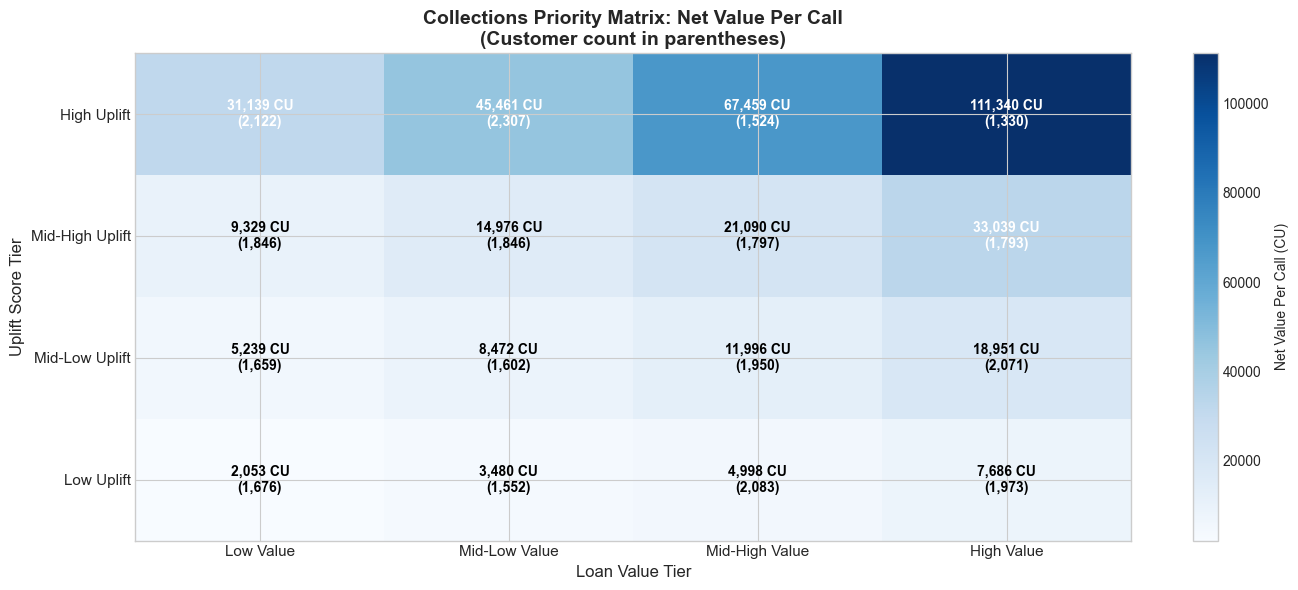

Collections Priority Ranking

Rank   Uplift Tier          Loan Tier           Customers  Net Value/Call
------------------------------------------------------------------------
1      High Uplift          High Value              1,330         111,340
2      High Uplift          Mid-High Value          1,524          67,459
3      High Uplift          Mid-Low Value           2,307          45,461
4      Mid-High Uplift      High Value              1,793          33,039
5      High Uplift          Low Value               2,122          31,139
6      Mid-High Uplift      Mid-High Value          1,797          21,090
7      Mid-Low Uplift       High Value              2,071          18,951
8      Mid-High Uplift      Mid-Low Value           1,846          14,976
9      Mid-Low Uplift       Mid-High Value          1,950          11,996
10     Mid-High Uplift      Low Value               1,846           9,329
11     Mid-Low Uplift       Mid-Low Value           1,602           8,472
12     Lo

In [11]:
# Create uplift and loan value tiers
persuadables['uplift_tier'] = pd.qcut(
    persuadables['uplift_t_learner'], q=4,
    labels=['Low Uplift', 'Mid-Low Uplift', 'Mid-High Uplift', 'High Uplift']
)

persuadables['loan_tier'] = pd.qcut(
    persuadables['AMT_CREDIT'], q=4,
    labels=['Low Value', 'Mid-Low Value', 'Mid-High Value', 'High Value'],
    duplicates='drop'
)

# Build priority matrix
matrix = persuadables.groupby(['uplift_tier', 'loan_tier'], observed=True).agg(
    customers=('TARGET', 'count'),
    avg_uplift=('uplift_t_learner', 'mean'),
    avg_loan=('AMT_CREDIT', 'mean'),
    net_value_per_call=('uplift_t_learner', lambda x: (x.mean() * persuadables.loc[x.index, 'AMT_CREDIT'].mean() * lgd) - cost_per_call)
).reset_index()

# Pivot for heatmap
heatmap_data = matrix.pivot_table(
    index='uplift_tier', columns='loan_tier',
    values='net_value_per_call', observed=True
)

# Reorder so High is at top
heatmap_data = heatmap_data.loc[
    ['High Uplift', 'Mid-High Uplift', 'Mid-Low Uplift', 'Low Uplift']
]

# Customer count pivot
count_data = matrix.pivot_table(
    index='uplift_tier', columns='loan_tier',
    values='customers', observed=True
)
count_data = count_data.loc[
    ['High Uplift', 'Mid-High Uplift', 'Mid-Low Uplift', 'Low Uplift']
]

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(heatmap_data.values, cmap='Blues', aspect='auto')

# Add text annotations
for i in range(len(heatmap_data)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        count = int(count_data.values[i, j])
        ax.text(j, i, f'{val:,.0f} CU\n({count:,})',
                ha='center', va='center', fontsize=10,
                color='white' if val > heatmap_data.values.mean() else 'black',
                fontweight='bold')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, fontsize=11)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=11)
ax.set_xlabel('Loan Value Tier', fontsize=12)
ax.set_ylabel('Uplift Score Tier', fontsize=12)
ax.set_title('Collections Priority Matrix: Net Value Per Call\n(Customer count in parentheses)',
             fontsize=14, fontweight='bold')

plt.colorbar(im, label='Net Value Per Call (CU)')
plt.tight_layout()
plt.show()

# Print ranked priorities
print("=" * 75)
print("Collections Priority Ranking")
print("=" * 75)
matrix_sorted = matrix.sort_values('net_value_per_call', ascending=False).reset_index(drop=True)
matrix_sorted.index = matrix_sorted.index + 1

print()
print(f"{'Rank':<6} {'Uplift Tier':<20} {'Loan Tier':<18} {'Customers':>10} {'Net Value/Call':>15}")
print("-" * 72)
for idx, row in matrix_sorted.iterrows():
    print(f"{idx:<6} {row['uplift_tier']:<20} {row['loan_tier']:<18} {int(row['customers']):>10,} {row['net_value_per_call']:>15,.0f}")
print("=" * 75)

# Clean up temporary columns
persuadables.drop(columns=['uplift_tier', 'loan_tier'], inplace=True)

### Collections Priority Matrix Finding

The matrix produces 16 cells ranked by net value per call. The top priority is clear:

**Rank 1**: High Uplift, High Value (1,330 customers, 111,340 CU per call). These customers
have the strongest response to intervention and the largest loans at risk. Every call to
this group prevents the most loss.

**Ranks 2-5**: High Uplift customers across all loan tiers, plus Mid-High Uplift with High
Value loans. These 9,076 customers form the top third of Persuadables and should be called
first.

**Ranks 6-11**: The middle tier. Still strongly positive returns (8,472 to 21,090 CU per call)
but lower urgency. If the collections team has limited capacity, these come second.

**Ranks 12-16**: Low uplift customers across all loan tiers. Returns range from 2,053 to
7,686 CU per call. Still profitable but the lowest priority among Persuadables.

The key takeaway: all 16 cells are profitable. The matrix does not determine who to skip
(that decision was made in Phase 4 with the quadrant segmentation). It determines the
order of operations when agent time is limited. Start at Rank 1, work down, stop when
the team runs out of capacity.

## Step 10 | Phase 5 Summary and Phase 6 Readiness

In [13]:
print("=" * 60)
print("PHASE 5 RESULTS")
print("=" * 60)
print()
print("PERSUADABLE PROFILE")
print(f"  Avg age              : {persuadables['AGE_YEARS'].mean():.1f} years")
print(f"  Avg income           : {persuadables['AMT_INCOME_TOTAL'].mean():,.0f} CU")
print(f"  Avg loan             : {persuadables['AMT_CREDIT'].mean():,.0f} CU")
print(f"  Avg DTI              : {persuadables['DEBT_TO_INCOME'].mean():.4f}")
print(f"  Avg baseline risk    : {persuadables['baseline_risk'].mean():.4f}")
print()
print("OPTIMAL TARGETING")
print(f"  Cutoff               : {optimal_customers:,} of {len(persuadables):,}")
print(f"  Peak cumulative gain : {peak_value:,.0f} CU")
print("=" * 60)

PHASE 5 RESULTS

PERSUADABLE PROFILE
  Avg age              : 42.3 years
  Avg income           : 121,734 CU
  Avg loan             : 708,024 CU
  Avg DTI              : 0.2849
  Avg baseline risk    : 0.1615

OPTIMAL TARGETING
  Cutoff               : 29,106 of 29,131
  Peak cumulative gain : 683,509,550 CU


### Phase 5 Verdict

Every segment analyzed is profitable. No income band, age group, employment type, education
level, or loan type should be excluded from the collections strategy.

The Persuadable is a 42-year-old mid-career professional with moderate income, moderate
external scores, and a DTI around 0.28. They are stressed but capable. The collections
call gives them a path back.

The priority matrix ranks all 29,131 Persuadables into 16 cells by uplift and loan value.
High Uplift, High Value customers (1,330 customers, 111,340 CU per call) are called first.
The collections team works down the ranking until agent capacity runs out.

Phase 6 will consolidate all findings into a decision report with a single recommendation:
full rollout, targeted rollout, extend experiment, or do not deploy.

In [14]:
df.to_csv('../data/processed/segmented_scores.csv', index=False)

print("=" * 45)
print(f"Saved: data/processed/segmented_scores.csv")
print(f"Shape: {df.shape}")
print("=" * 45)

Saved: data/processed/segmented_scores.csv
Shape: (71904, 96)
